# RealWorld HAR — Deep Learning Model Comparison (LOSO Cross-Validation)

This notebook trains and compares five deep learning architectures on the
raw-signal windows extracted from RealWorld (`X_windows.npy` / `y_windows.npy`
/ `groups.npy`), using Leave-One-Subject-Out (LOSO) cross-validation.

Models compared:
- DNN (fully-connected baseline)
- CNN1D
- RNN
- DeepConvLSTM
- TinyHAR (official architecture, ISWC'22)

Each model is trained per fold with an inner validation subject for
early stopping (test subject stays fully blind until final evaluation —
no leakage).

In [7]:
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.13.0
CUDA available: True
GPU: NVIDIA H100 80GB HBM3 MIG 1g.10gb


Reproducibility

In [9]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Load Windowed Data

In [10]:
DATA_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")

X = np.load(DATA_DIR / "X_windows.npy")
y = np.load(DATA_DIR / "y_windows.npy")
groups = np.load(DATA_DIR / "groups.npy")

activity_classes = np.load(DATA_DIR / "activity_classes.npy", allow_pickle=True)
participant_classes = np.load(DATA_DIR / "participant_classes.npy", allow_pickle=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Activities:", list(activity_classes))
print("Participants:", list(participant_classes))

X shape: (435295, 100, 9)
y shape: (435295,)
groups shape: (435295,)
Activities: [np.str_('climbingdown'), np.str_('climbingup'), np.str_('jumping'), np.str_('lying'), np.str_('running'), np.str_('sitting'), np.str_('standing'), np.str_('walking')]
Participants: [np.str_('proband1'), np.str_('proband10'), np.str_('proband11'), np.str_('proband12'), np.str_('proband13'), np.str_('proband14'), np.str_('proband15'), np.str_('proband2'), np.str_('proband3'), np.str_('proband4'), np.str_('proband5'), np.str_('proband6'), np.str_('proband7'), np.str_('proband8'), np.str_('proband9')]


Configuration

In [11]:
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 7
GRAD_CLIP_NORM = 5.0

INPUT_WINDOW = X.shape[1]      # 100
INPUT_FEATURES = X.shape[2]    # 9
NUM_CLASSES = len(activity_classes)  # 8

RANDOM_SEED = 42

print(f"Window: {INPUT_WINDOW} | Features: {INPUT_FEATURES} | Classes: {NUM_CLASSES}")

Window: 100 | Features: 9 | Classes: 8


Dataset Class

In [12]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Model Architectures

Same architectures used in the earlier student-dataset comparison, kept
identical here so results are directly comparable across datasets.

 DNN

In [13]:
class DNNClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes):
        super().__init__()
        input_dim = input_window * input_features
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

CNN1D

In [14]:
class CNN1DClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, input_features, input_window)
            flat_dim = self.conv(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, window)
        x = self.conv(x)
        return self.classifier(x)

RNN

In [15]:
class RNNClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes, hidden_size=128):
        super().__init__()
        self.rnn = nn.RNN(input_features, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return self.classifier(out)

DeepConvLSTM

In [16]:
class DeepConvLSTMClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128, 32)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.dropout2(self.relu(self.fc1(out)))
        return self.classifier(out)

## TinyHAR (Official Architecture)

Imported from the ISWC'22 repository. Wrapped so it accepts the same
`(batch, window, features)` input as the other models, and internally
reshapes to the `(batch, 1, window, features)` shape the original
architecture expects.

In [17]:
import sys
sys.path.insert(0, "/lustre09/project/6081099/reem2005/ISWC22-HAR-main")
from models.TinyHAR import TinyHAR_Model

class TinyHARClassifier(nn.Module):
    def __init__(self, input_window, input_features, num_classes, filter_num=32):
        super().__init__()
        input_shape = (1, 1, input_window, input_features)
        self.model = TinyHAR_Model(
            input_shape=input_shape,
            number_class=num_classes,
            filter_num=filter_num,
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, window, features) -> (batch, 1, window, features)
        return self.model(x)

 Model Registry

In [18]:
MODEL_REGISTRY = {
    "dnn": DNNClassifier,
    "cnn1d": CNN1DClassifier,
    "rnn": RNNClassifier,
    "deepconv_lstm": DeepConvLSTMClassifier,
    "tinyhar": TinyHARClassifier,
}

print("Models to compare:", list(MODEL_REGISTRY.keys()))

Models to compare: ['dnn', 'cnn1d', 'rnn', 'deepconv_lstm', 'tinyhar']


Train / Evaluate Functions

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, all_labels, all_preds

## LOSO Runner

For each held-out test subject, one additional subject is drawn from the
remaining training subjects to serve as the inner validation set (for
early stopping and best-epoch selection). The test subject is never
touched until the final evaluation — no leakage.

LOSO Experiment Function

In [14]:
def run_loso_experiment(model_name, epochs=EPOCHS, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    unique_subjects = np.unique(groups)

    fold_f1s = []
    fold_accuracies = []
    all_y_true, all_y_pred = [], []

    for fold, test_subject in enumerate(unique_subjects, 1):
        train_subjects_all = unique_subjects[unique_subjects != test_subject]

        rng = np.random.RandomState(RANDOM_SEED + fold)
        val_subject = rng.choice(train_subjects_all)
        train_subjects = train_subjects_all[train_subjects_all != val_subject]

        train_mask = np.isin(groups, train_subjects)
        val_mask = groups == val_subject
        test_mask = groups == test_subject

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        train_loader = DataLoader(HARDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(HARDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(HARDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

        model = MODEL_REGISTRY[model_name](INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)

        class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
        class_weights = torch.tensor(
            len(y_train) / (NUM_CLASSES * np.maximum(class_counts, 1)), dtype=torch.float32
        ).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

        best_val_f1 = -1
        best_model_state = None
        patience_counter = 0

        for epoch in range(epochs):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_f1)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break

        model.load_state_dict(best_model_state)
        test_loss, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)
        test_acc = accuracy_score(y_true, y_pred)

        fold_f1s.append(test_f1)
        fold_accuracies.append(test_acc)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        if verbose:
            print(f"  [{model_name}] Fold {fold:2d} | test={participant_classes[test_subject]:10s} | "
                  f"Acc={test_acc:.4f} | F1={test_f1:.4f}")

    return {
        "model_name": model_name,
        "fold_f1s": fold_f1s,
        "fold_accuracies": fold_accuracies,
        "mean_f1": np.mean(fold_f1s),
        "std_f1": np.std(fold_f1s),
        "mean_accuracy": np.mean(fold_accuracies),
        "std_accuracy": np.std(fold_accuracies),
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    }

Main Training Loop


In [15]:
all_results = {}

print(f"{'MODEL':<16} {'MEAN ACC':>10} {'MEAN F1':>10} {'STD F1':>8} {'TIME (min)':>12}")
print("=" * 60)

for model_name in MODEL_REGISTRY:
    print(f"\n{'=' * 60}")
    print(f"Training: {model_name}")
    print(f"{'=' * 60}")

    t0 = time.time()
    result = run_loso_experiment(model_name, epochs=EPOCHS, verbose=True)
    elapsed = time.time() - t0

    result["elapsed_minutes"] = elapsed / 60
    all_results[model_name] = result

    print(f"\n--- {model_name} summary ---")
    print(f"Mean Accuracy : {result['mean_accuracy']:.4f} ± {result['std_accuracy']:.4f}")
    print(f"Mean Macro F1 : {result['mean_f1']:.4f} ± {result['std_f1']:.4f}")
    print(f"Time          : {elapsed/60:.1f} min")

print("\n" + "=" * 60)
print("FINAL COMPARISON — ALL MODELS")
print("=" * 60)
for name, res in sorted(all_results.items(), key=lambda kv: kv[1]["mean_f1"], reverse=True):
    print(f"{name:<16} {res['mean_accuracy']:>10.4f} {res['mean_f1']:>10.4f} "
          f"{res['std_f1']:>8.4f} {res['elapsed_minutes']:>12.1f}")

MODEL              MEAN ACC    MEAN F1   STD F1   TIME (min)

Training: dnn
  [dnn] Fold  1 | test=proband1   | Acc=0.6492 | F1=0.6575
  [dnn] Fold  2 | test=proband10  | Acc=0.6271 | F1=0.5910
  [dnn] Fold  3 | test=proband11  | Acc=0.6934 | F1=0.7082
  [dnn] Fold  4 | test=proband12  | Acc=0.6357 | F1=0.6477
  [dnn] Fold  5 | test=proband13  | Acc=0.6913 | F1=0.7022
  [dnn] Fold  6 | test=proband14  | Acc=0.6037 | F1=0.6084
  [dnn] Fold  7 | test=proband15  | Acc=0.6324 | F1=0.6496
  [dnn] Fold  8 | test=proband2   | Acc=0.6590 | F1=0.6745
  [dnn] Fold  9 | test=proband3   | Acc=0.5863 | F1=0.6241
  [dnn] Fold 10 | test=proband4   | Acc=0.5436 | F1=0.5648
  [dnn] Fold 11 | test=proband5   | Acc=0.5238 | F1=0.5559
  [dnn] Fold 12 | test=proband6   | Acc=0.6371 | F1=0.6520
  [dnn] Fold 13 | test=proband7   | Acc=0.6523 | F1=0.6623
  [dnn] Fold 14 | test=proband8   | Acc=0.4521 | F1=0.4885
  [dnn] Fold 15 | test=proband9   | Acc=0.5741 | F1=0.6084

--- dnn summary ---
Mean Accuracy : 0.

In [1]:
tinyhar_result = all_results["tinyhar"]

print("TinyHAR — F1 per fold (sorted worst to best)")
print("=" * 50)

fold_breakdown = list(zip(participant_classes, tinyhar_result["fold_f1s"]))
fold_breakdown_sorted = sorted(fold_breakdown, key=lambda x: x[1])

for subj, f1 in fold_breakdown_sorted:
    marker = " ⚠️ " if f1 < tinyhar_result["mean_f1"] - tinyhar_result["std_f1"] else "    "
    print(f"{marker}{subj:12s} | F1={f1:.4f}")

print(f"\nMean: {tinyhar_result['mean_f1']:.4f} | Std: {tinyhar_result['std_f1']:.4f}")

NameError: name 'all_results' is not defined

In [16]:
summary_df = pd.DataFrame([
    {
        "model": name,
        "mean_f1_macro": res["mean_f1"],
        "std_f1_macro": res["std_f1"],
        "overall_accuracy": accuracy_score(res["y_true"], res["y_pred"]),
        "time_minutes": res["elapsed_minutes"],
    }
    for name, res in all_results.items()
]).sort_values("mean_f1_macro", ascending=False).reset_index(drop=True)

summary_df

,model,mean_f1_macro,std_f1_macro,overall_accuracy,time_minutes
0,cnn1d,0.730916,0.063267,0.708039,35.183295
1,deepconv_lstm,0.710548,0.059344,0.695119,74.675319
2,tinyhar,0.683232,0.060272,0.660685,308.083203
3,dnn,0.626336,0.056775,0.607636,32.146004
4,rnn,0.492478,0.067329,0.490929,26.055670


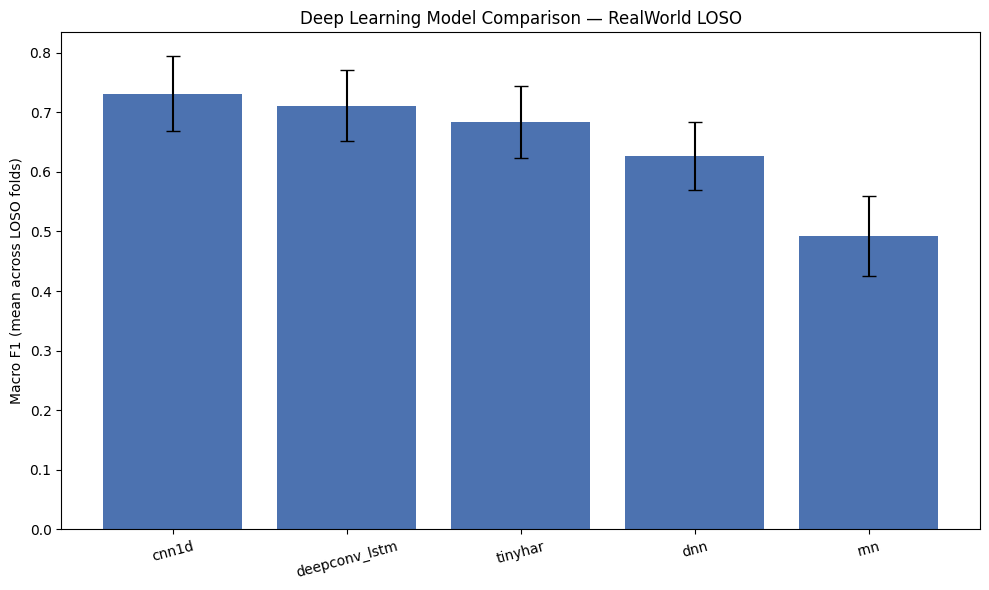

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary_df["model"], summary_df["mean_f1_macro"],
    yerr=summary_df["std_f1_macro"], capsize=5, color="#4C72B0"
)
plt.ylabel("Macro F1 (mean across LOSO folds)")
plt.title("Deep Learning Model Comparison — RealWorld LOSO")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Best model: cnn1d
              precision    recall  f1-score   support

climbingdown     0.7868    0.7846    0.7857     48295
  climbingup     0.8304    0.7505    0.7884     59670
     jumping     0.8381    0.9194    0.8769      9259
       lying     0.6543    0.7363    0.6929     62692
     running     0.9502    0.7943    0.8653     68882
     sitting     0.4826    0.4175    0.4477     62525
    standing     0.5197    0.6569    0.5803     61542
     walking     0.7870    0.7946    0.7908     62430

    accuracy                         0.7080    435295
   macro avg     0.7311    0.7318    0.7285    435295
weighted avg     0.7192    0.7080    0.7104    435295



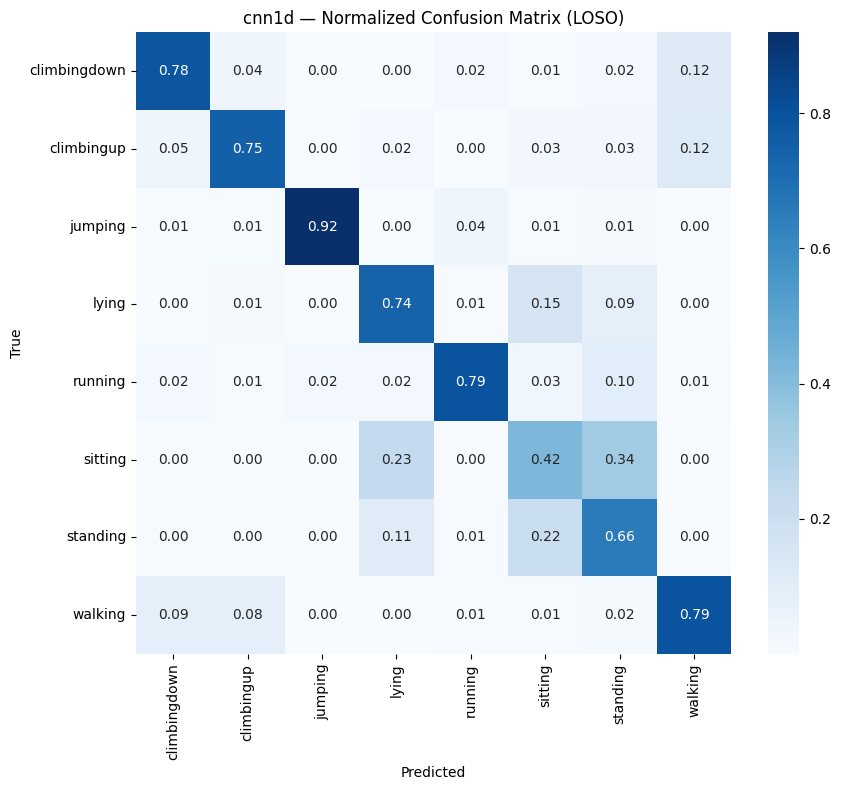

In [18]:
best_model_name = summary_df.iloc[0]["model"]
best_result = all_results[best_model_name]

print(f"Best model: {best_model_name}")
print("=" * 60)
print(classification_report(
    best_result["y_true"], best_result["y_pred"],
    target_names=list(activity_classes), digits=4
))

cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_normalized, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=activity_classes, yticklabels=activity_classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{best_model_name} — Normalized Confusion Matrix (LOSO)")
plt.tight_layout()
plt.show()

In [19]:
RESULTS_OUTPUT = DATA_DIR / "dl_loso_results.pkl"
pd.to_pickle(all_results, RESULTS_OUTPUT)
print("Saved:", RESULTS_OUTPUT)

Saved: /lustre09/project/6081099/reem2005/DATASET/PROCESSED/dl_loso_results.pkl


## Summary

- Trained 5 deep learning architectures with LOSO cross-validation on
  RealWorld (435,295 windows, 15 subjects, 8 activities)
- Leakage-free: inner validation subject used for early stopping; test
  subject held out entirely until final evaluation
- Class-balanced loss weighting applied per fold (train-set only)

**Next step:** compare against the classical ML (Random Forest, SVM, etc.)
results from the feature-extraction notebook.

In [2]:
from pathlib import Path

DATA_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")
saved_file = DATA_DIR / "dl_loso_results.pkl"

if saved_file.exists():
    print("✅ لقيت ملف محفوظ! تاريخ آخر تعديل:")
    import datetime
    print(datetime.datetime.fromtimestamp(saved_file.stat().st_mtime))
else:
    print("❌ ما في ملف محفوظ — لازم نعيد كل شي من الصفر")

✅ لقيت ملف محفوظ! تاريخ آخر تعديل:
2026-07-17 05:30:36


In [4]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")
RESULTS_OUTPUT = DATA_DIR / "dl_loso_results.pkl"

all_results = pd.read_pickle(RESULTS_OUTPUT)

print("الموديلات المحفوظة:", list(all_results.keys()))
print("\n" + "=" * 60)
print("FINAL COMPARISON — ALL MODELS")
print("=" * 60)
print(f"{'MODEL':<16} {'MEAN ACC':>10} {'MEAN F1':>10} {'STD F1':>8} {'TIME (min)':>12}")
for name, res in sorted(all_results.items(), key=lambda kv: kv[1]["mean_f1"], reverse=True):
    print(f"{name:<16} {res.get('mean_accuracy', 0):>10.4f} {res['mean_f1']:>10.4f} "
          f"{res['std_f1']:>8.4f} {res.get('elapsed_minutes', 0):>12.1f}")

الموديلات المحفوظة: ['dnn', 'cnn1d', 'rnn', 'deepconv_lstm', 'tinyhar']

FINAL COMPARISON — ALL MODELS
MODEL              MEAN ACC    MEAN F1   STD F1   TIME (min)
cnn1d                0.7116     0.7309   0.0633         35.2
deepconv_lstm        0.6980     0.7105   0.0593         74.7
tinyhar              0.6619     0.6832   0.0603        308.1
dnn                  0.6107     0.6263   0.0568         32.1
rnn                  0.4934     0.4925   0.0673         26.1


In [5]:
import numpy as np

participant_classes = np.load(DATA_DIR / "participant_classes.npy", allow_pickle=True)

tinyhar_result = all_results["tinyhar"]

print("TinyHAR — F1 per fold (sorted worst to best)")
print("=" * 50)

fold_breakdown = list(zip(participant_classes, tinyhar_result["fold_f1s"]))
fold_breakdown_sorted = sorted(fold_breakdown, key=lambda x: x[1])

for subj, f1 in fold_breakdown_sorted:
    marker = " ⚠️ " if f1 < tinyhar_result["mean_f1"] - tinyhar_result["std_f1"] else "    "
    print(f"{marker}{subj:12s} | F1={f1:.4f}")

print(f"\nMean: {tinyhar_result['mean_f1']:.4f} | Std: {tinyhar_result['std_f1']:.4f}")

TinyHAR — F1 per fold (sorted worst to best)
 ⚠️ proband14    | F1=0.5725
 ⚠️ proband2     | F1=0.6055
 ⚠️ proband8     | F1=0.6155
    proband5     | F1=0.6350
    proband4     | F1=0.6374
    proband10    | F1=0.6425
    proband1     | F1=0.6840
    proband3     | F1=0.6885
    proband9     | F1=0.7109
    proband15    | F1=0.7223
    proband7     | F1=0.7238
    proband12    | F1=0.7302
    proband13    | F1=0.7310
    proband11    | F1=0.7624
    proband6     | F1=0.7871

Mean: 0.6832 | Std: 0.0603


In [20]:
def run_loso_experiment(model_name, epochs=EPOCHS, patience=PATIENCE, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    unique_subjects = np.unique(groups)

    fold_f1s = []
    fold_accuracies = []
    all_y_true, all_y_pred = [], []

    for fold, test_subject in enumerate(unique_subjects, 1):
        train_subjects_all = unique_subjects[unique_subjects != test_subject]

        rng = np.random.RandomState(RANDOM_SEED + fold)
        val_subject = rng.choice(train_subjects_all)
        train_subjects = train_subjects_all[train_subjects_all != val_subject]

        train_mask = np.isin(groups, train_subjects)
        val_mask = groups == val_subject
        test_mask = groups == test_subject

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        train_loader = DataLoader(HARDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(HARDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(HARDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

        model = MODEL_REGISTRY[model_name](INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)

        class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
        class_weights = torch.tensor(
            len(y_train) / (NUM_CLASSES * np.maximum(class_counts, 1)), dtype=torch.float32
        ).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

        best_val_f1 = -1
        best_model_state = None
        patience_counter = 0

        for epoch in range(epochs):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_f1)

            if verbose:
                print(f"    epoch {epoch+1:2d} | train_loss={train_loss:.4f} | val_f1={val_f1:.4f}")

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        model.load_state_dict(best_model_state)
        test_loss, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)
        test_acc = accuracy_score(y_true, y_pred)

        fold_f1s.append(test_f1)
        fold_accuracies.append(test_acc)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        if verbose:
            print(f"  [{model_name}] Fold {fold:2d} | test={participant_classes[test_subject]:10s} | "
                  f"Acc={test_acc:.4f} | F1={test_f1:.4f}")

    return {
        "model_name": model_name,
        "fold_f1s": fold_f1s,
        "fold_accuracies": fold_accuracies,
        "mean_f1": np.mean(fold_f1s),
        "std_f1": np.std(fold_f1s),
        "mean_accuracy": np.mean(fold_accuracies),
        "std_accuracy": np.std(fold_accuracies),
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    }

In [ ]:
import gc

t0 = time.time()
tinyhar_result_v2 = run_loso_experiment("tinyhar", epochs=EPOCHS, patience=12, verbose=True)
elapsed = time.time() - t0

tinyhar_result_v2["elapsed_minutes"] = elapsed / 60

# احتفظ بالنسخة القديمة تحسباً، واستبدل بالجديدة كنتيجة رسمية
all_results["tinyhar_old"] = all_results["tinyhar"]
all_results["tinyhar"] = tinyhar_result_v2

print(f"\n{'='*60}")
print(f"OLD TinyHAR — Mean F1: {all_results['tinyhar_old']['mean_f1']:.4f} ± {all_results['tinyhar_old']['std_f1']:.4f}")
print(f"NEW TinyHAR — Mean F1: {tinyhar_result_v2['mean_f1']:.4f} ± {tinyhar_result_v2['std_f1']:.4f}")
print(f"Time: {elapsed/60:.1f} min")
print(f"{'='*60}")

# حفظ فوري (احتياطاً من موت الكيرنل تاني)
pd.to_pickle(all_results, RESULTS_OUTPUT)
print(f"💾 تم الحفظ: {RESULTS_OUTPUT}")

# تنظيف الذاكرة
torch.cuda.empty_cache()
gc.collect()

    epoch  1 | train_loss=0.8619 | val_f1=0.5761
